In [ ]:
# import the file
import pandas as pd
import numpy as np
df = pd.read_csv("bank-full.csv")
df
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
# EDA
df.isnull().sum()
df.duplicated().sum()
df.info()

categorical_data=['job','marital','education','default','housing','loan','contact','month','poutcome','y']
categorical_data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

In [ ]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()


In [ ]:
for col in categorical_data:
    df[col] = LE.fit_transform(df[col])

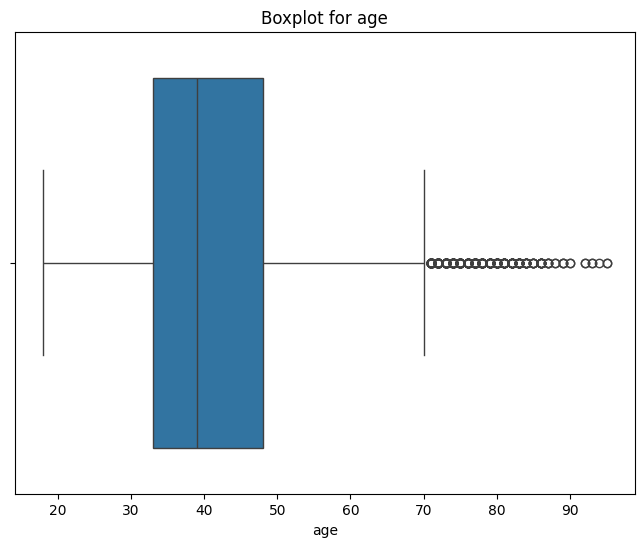

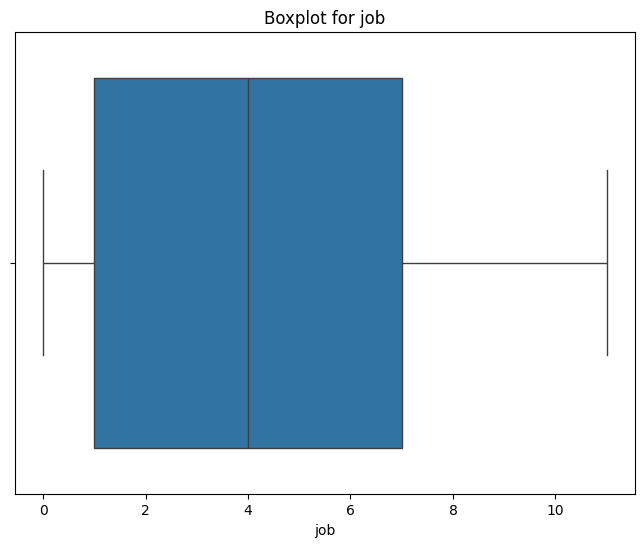

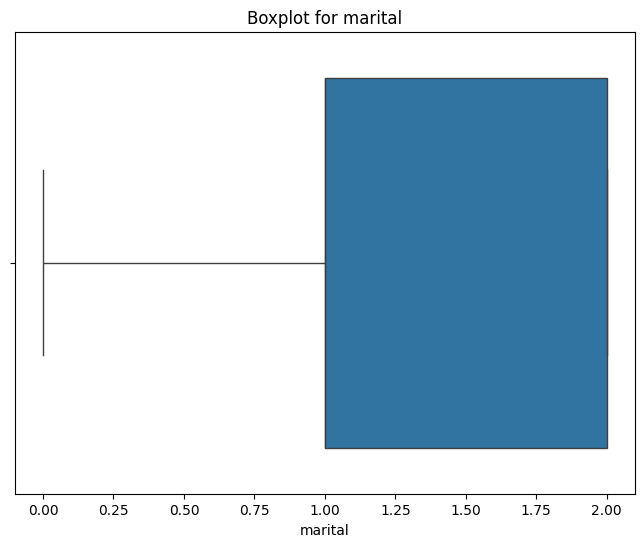

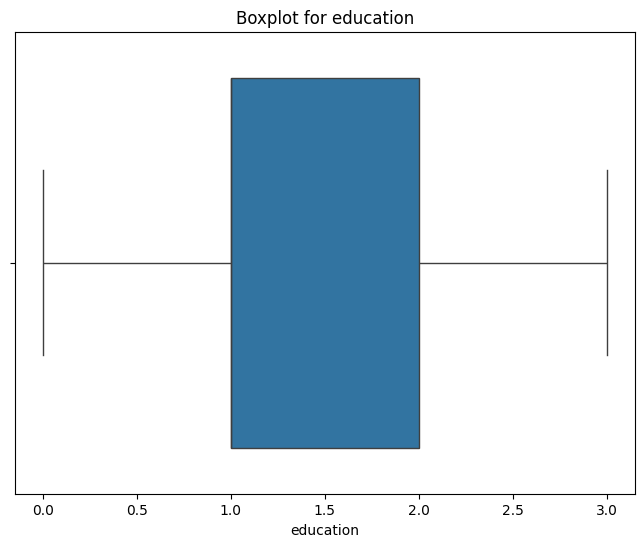

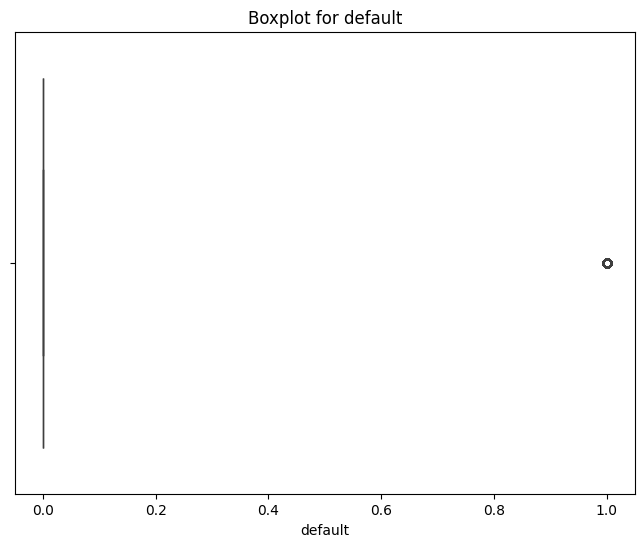

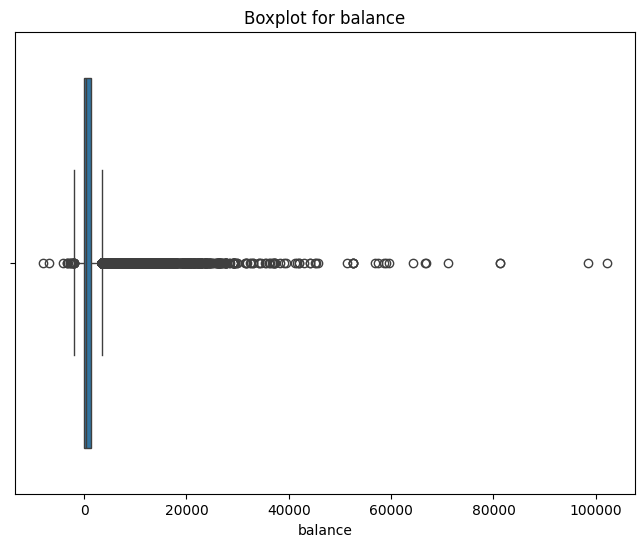

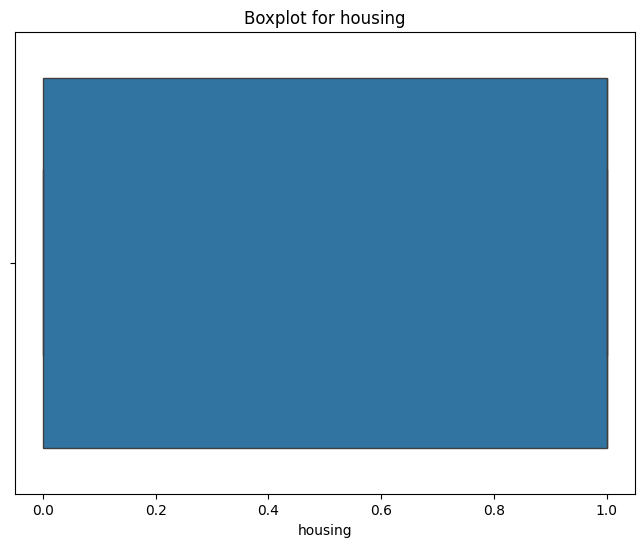

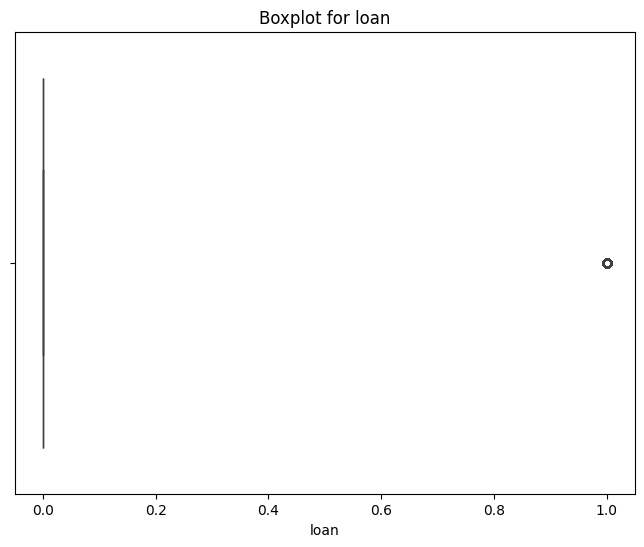

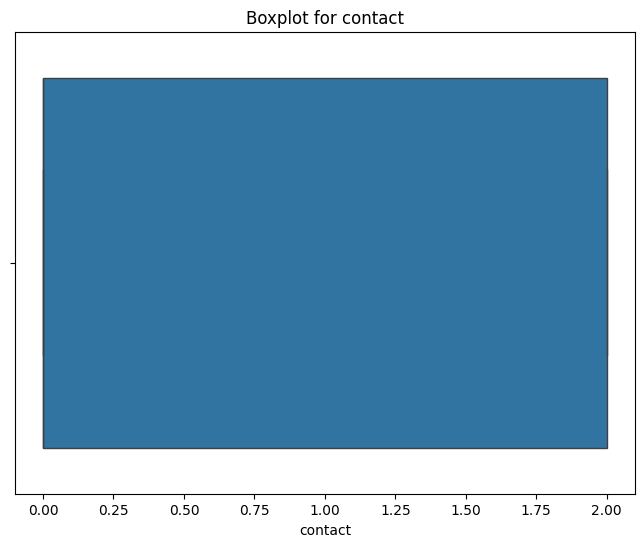

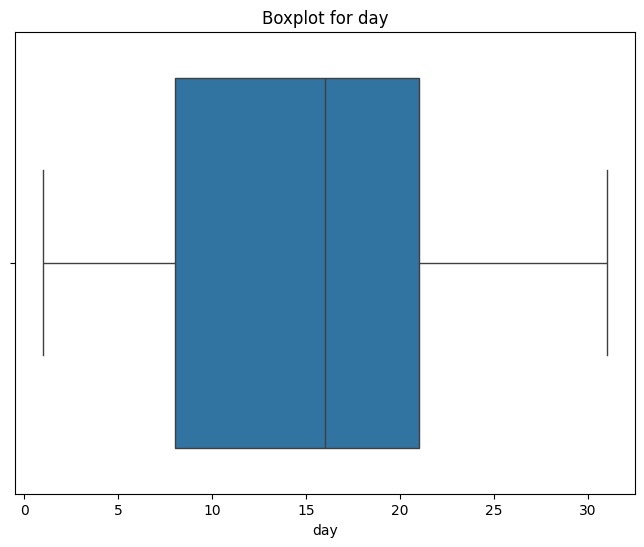

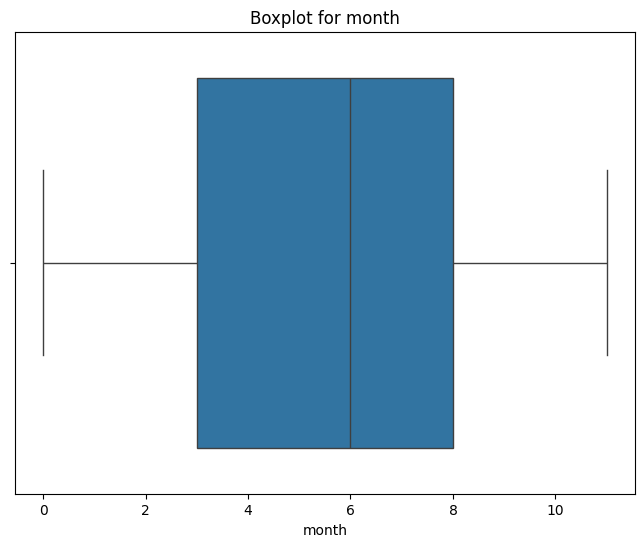

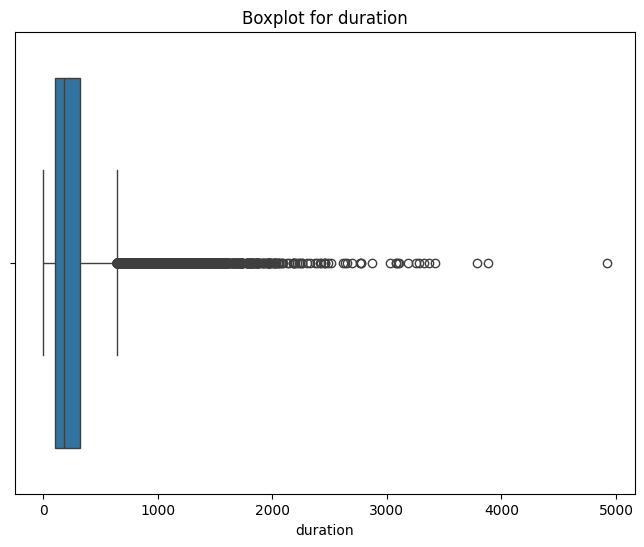

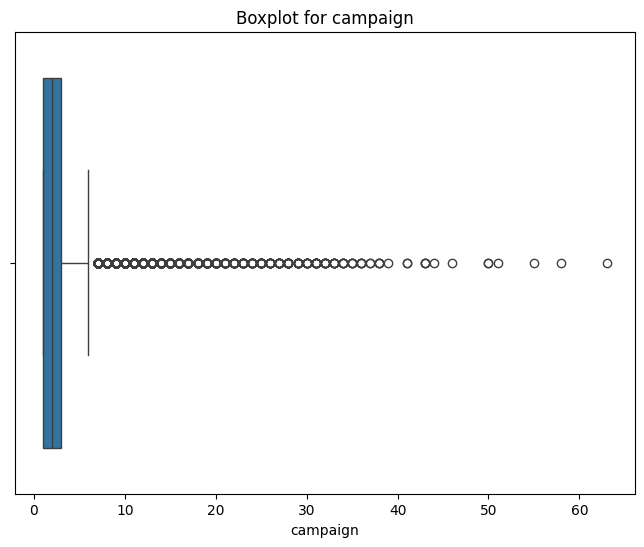

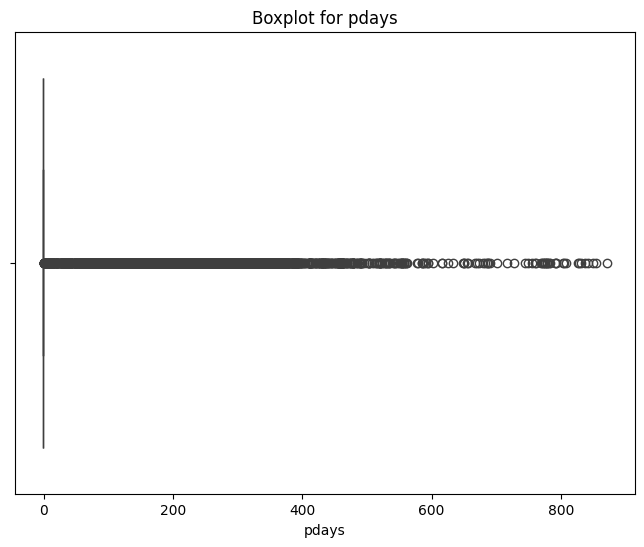

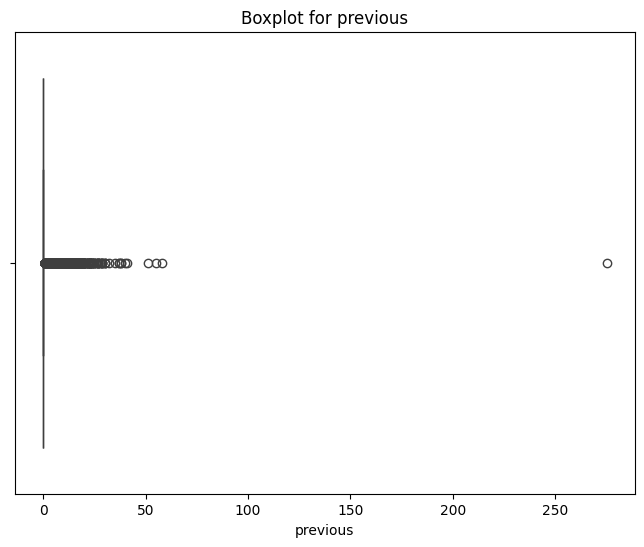

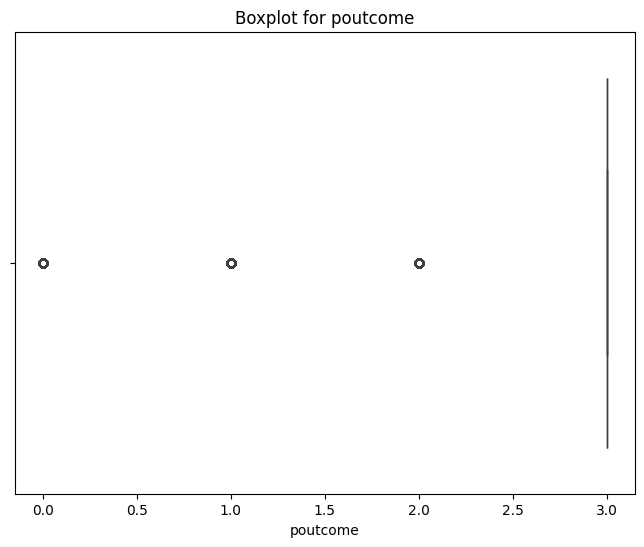

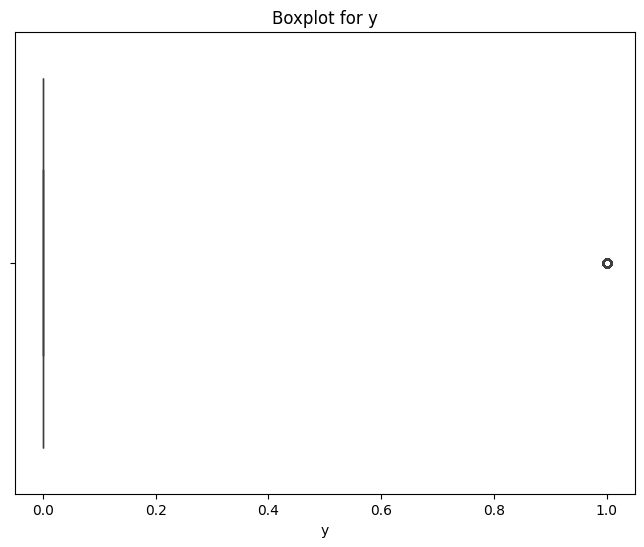

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
for column in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=column, data=df)
    plt.title(f'Boxplot for {column}')
    plt.show()

In [ ]:
#spliting variables
Y=df['y']
Y
X=df.iloc[:,:16]
X

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,9,1,2,0,825,0,0,0,17,9,977,3,-1,0,3
45207,71,5,0,0,0,1729,0,0,0,17,9,456,2,-1,0,3
45208,72,5,1,1,0,5715,0,0,0,17,9,1127,5,184,3,2
45209,57,1,1,1,0,668,0,0,1,17,9,508,4,-1,0,3


In [ ]:
# standardization
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
SS_X = SS.fit_transform(X)
pd.DataFrame(SS_X)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1.606965,-0.103820,-0.275762,1.036362,-0.13549,0.256419,0.893915,-0.436803,1.514306,-1.298476,0.823773,0.011016,-0.569351,-0.411453,-0.251940,0.444898
1,0.288529,1.424008,1.368372,-0.300556,-0.13549,-0.437895,0.893915,-0.436803,1.514306,-1.298476,0.823773,-0.416127,-0.569351,-0.411453,-0.251940,0.444898
2,-0.747384,-0.714951,-0.275762,-0.300556,-0.13549,-0.446762,0.893915,2.289359,1.514306,-1.298476,0.823773,-0.707361,-0.569351,-0.411453,-0.251940,0.444898
3,0.571051,-1.020516,-0.275762,2.373280,-0.13549,0.047205,0.893915,-0.436803,1.514306,-1.298476,0.823773,-0.645231,-0.569351,-0.411453,-0.251940,0.444898
4,-0.747384,2.035139,1.368372,2.373280,-0.13549,-0.447091,-1.118674,-0.436803,1.514306,-1.298476,0.823773,-0.233620,-0.569351,-0.411453,-0.251940,0.444898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,0.947747,1.424008,-0.275762,1.036362,-0.13549,-0.176460,-1.118674,-0.436803,-0.713012,0.143418,1.156344,2.791329,0.076230,-0.411453,-0.251940,0.444898
45207,2.831227,0.201746,-1.919895,-1.637474,-0.13549,0.120447,-1.118674,-0.436803,-0.713012,0.143418,1.156344,0.768224,-0.246560,-0.411453,-0.251940,0.444898
45208,2.925401,0.201746,-0.275762,-0.300556,-0.13549,1.429593,-1.118674,-0.436803,-0.713012,0.143418,1.156344,3.373797,0.721811,1.436189,1.050473,-0.566175
45209,1.512791,-1.020516,-0.275762,-0.300556,-0.13549,-0.228024,-1.118674,-0.436803,0.400647,0.143418,1.156344,0.970146,0.399020,-0.411453,-0.251940,0.444898


In [ ]:
# Data partition
from sklearn.model_selection import train_test_split
Xtrain,Xtest,Ytrain,Ytest = train_test_split(SS_X,Y,test_size=0.30,random_state=10)

In [ ]:
# Model fitting
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()
lg.fit(Xtrain,Ytrain)

LogisticRegression()

In [ ]:
# predictions
Ypred_train = lg.predict(Xtrain)
Ypred_test  = lg.predict(Xtest)

In [ ]:
# Metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
ac1 = accuracy_score(Ytrain ,Ypred_train)
print("Train Accuracy score:", ac1.round(3))

ac2 = accuracy_score(Ytest ,Ypred_test)
print("Test Accuracy score:", ac2.round(3))

cm=confusion_matrix(Ytest,Ypred_test)
cm

cr=classification_report(Ytest,Ypred_test)
print(cr)

Train Accuracy score: 0.89
Test Accuracy score: 0.893
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     12006
           1       0.59      0.22      0.33      1558

    accuracy                           0.89     13564
   macro avg       0.75      0.60      0.63     13564
weighted avg       0.87      0.89      0.87     13564



In [ ]:
# exact probabilities
lg.predict_proba(Xtest) # 1- prob, prob
Yproba = lg.predict_proba(Xtest)[:,1:]


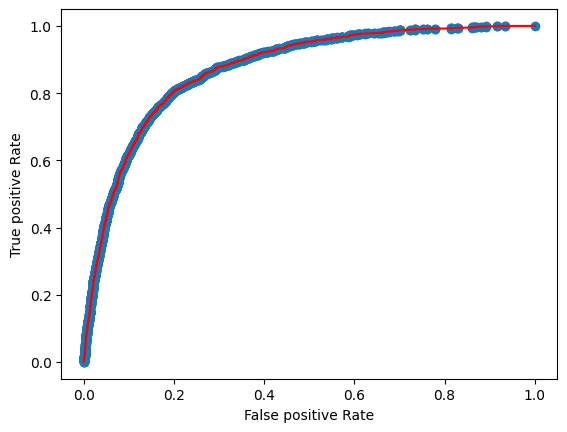

AUC score: 0.872


In [ ]:
# ROC CURVE

from sklearn.metrics import roc_curve,roc_auc_score
fpr,tpr,threshold = roc_curve(Ytest,Yproba)

import matplotlib.pyplot as plt
plt.scatter(x = fpr,y=tpr)
plt.plot(fpr,tpr,color='red')
plt.ylabel("True positive Rate")
plt.xlabel("False positive Rate")
plt.show()

print("AUC score:", roc_auc_score(Ytest,Yproba).round(3))

In [ ]:
threshold

array([2.00000000e+00, 1.00000000e+00, 9.99999853e-01, ...,
       8.23066245e-03, 8.22801034e-03, 1.97329588e-05])

In [ ]:
len(threshold)

2067

In [ ]:
accuracy = []
for i in threshold:
    y_pred = np.where(Yproba > i, 1, 0)
    accuracy.append(accuracy_score(Ytest, y_pred))

final_threshold = pd.DataFrame({'threshold': threshold, 'Accuracy': accuracy})
final_threshold = final_threshold.sort_values(by='Accuracy', ascending=False)

best_threshold = final_threshold.iloc[0]['threshold']
best_threshold

from sklearn.preprocessing import binarize
Yproba_2d = Yproba.reshape(-1, 1)  # Ensure Yproba is a 2D array
y_thresholded = binarize(Yproba_2d, threshold=best_threshold)[:, 0]

print(classification_report(Ytest, y_thresholded))

print(confusion_matrix(Ytest, y_thresholded))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94     12006
           1       0.59      0.24      0.34      1558

    accuracy                           0.89     13564
   macro avg       0.75      0.61      0.64     13564
weighted avg       0.87      0.89      0.87     13564

[[11750   256]
 [ 1183   375]]
